# Exercitiul 1

Use a GRU with $2$ recurrent layers for the decoder part. Train the model for $1$ epoch and evaluate it on an instance from the test set.

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import spacy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

In [ ]:
def download(url, cache_dir=os.path.join('.', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    fp = None
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flicker8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')

spacy_en = spacy.load('en_core_web_sm')

In [ ]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<BOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1

                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

def load_captions(path):
    captions_list = []
    image_captions = {}
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            caption = ' '.join(words[1:])
            captions_list.append(caption)

    return captions_list



In [ ]:
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))

In [ ]:
def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_name = line.strip("\n").split(".")[0]
            img_names.append(img_name)

    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]

            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)

    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x:x + '\n', lines)
        file.writelines(lines)

split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")

In [ ]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform

        # Get img, caption columns
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)

        return imgs, targets

def get_loader(
    root_folder,
    annotation_file,
    vocab,
    transform,
    batch_size=32,
    num_workers=2,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]),
    )

    return loader, dataset

In [ ]:
transform = transforms.Compose(
        [transforms.Resize((299, 299)),
         transforms.ToTensor(),
         transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
         ]
    )

train_loader, train_dataset = get_loader(
    "Flicker8k_Dataset", "train.txt", vocab, transform=transform
)

val_loader, val_dataset = get_loader(
    "Flicker8k_Dataset", "validation.txt", vocab, transform=transform
)

test_loader, test_dataset = get_loader(
    "Flicker8k_Dataset", "test.txt", vocab, transform=transform, shuffle=False
)

In [ ]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):

        features = self.inception(images)
        if isinstance(features, tuple):
            features = features[0]
        return self.dropout(self.relu(features))


In [ ]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers=2)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        _, initial_hiddens = self.gru(features.unsqueeze(0))

        hiddens, states = self.gru(embeddings, initial_hiddens)
        outputs = self.linear(hiddens)
        return outputs

In [ ]:
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=40):
        result_caption = []

        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)

            initial_hiddens = self.decoderRNN.gru(x)[1]
            states = initial_hiddens

            for _ in range(max_length):
                hiddens, states = self.decoderRNN.gru(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(1)
                predicted_item = predicted.item()
                result_caption.append(predicted_item)
                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocabulary.itos[predicted_item] == "<EOS>":
                    break

        return [vocabulary.itos[idx] for idx in result_caption]

In [ ]:
embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
####
num_layers = 2
learning_rate = 3e-4
num_epochs = 1
device = try_gpu()

In [ ]:
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 128MB/s] 


In [ ]:
for name, param in model.encoderCNN.inception.named_parameters():
        if "fc.weight" in name or "fc.bias" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
loss_criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])


[Train 1] Iteration 100 | Running Loss: 8.0204
[Train 1] Iteration 200 | Running Loss: 8.0177
[Train 1] Iteration 300 | Running Loss: 8.0145
[Train 1] Iteration 400 | Running Loss: 8.0119
[Train 1] Iteration 500 | Running Loss: 8.0090
[Train 1] Iteration 600 | Running Loss: 8.0062
[Train 1] Iteration 700 | Running Loss: 8.0034
[Train 1] Iteration 800 | Running Loss: 8.0007
[Train 1] Iteration 900 | Running Loss: 7.9978
[Train] Epoch 1 | Average Loss: 7.9968
[Valid] Epoch 1 | Average Loss: 7.9709
Example CORRECT: a blond woman in a blue shirt appears to wait for a ride .
Example OUTPUT: japanese weather fruit glacier clapping whistle barrel leggings bib hound hound lion showing youth tails rod boxer splashing aqua aqua rollerblading residential bound sucking sucking outstreached outstreached ticket ticket ticket ticket pot diner diner first sitting soaking pours shows serve


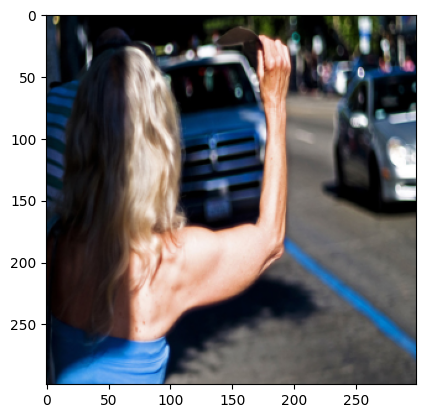

In [ ]:
train_loss = []
dev_loss = []

for epoch in range(num_epochs):
    model.train()

    train_run_loss = []
    dev_run_loss = []
    index = 0

    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        outputs = model(imgs, captions)
        loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
        loss.backward()
        optimizer.step()
        train_run_loss.append(loss.item())
        if (index+1) % 100 == 0:
            print(f"[Train {epoch+1}] Iteration {index+1} | Running Loss: {np.mean(train_run_loss):.4f}")
        index += 1

    avg_loss = np.mean(train_run_loss)
    train_loss.append(avg_loss)
    print(f"[Train] Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")

    index = 0
    for idx, (imgs, captions) in enumerate(val_loader):
        with torch.no_grad():
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions)
            loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
            dev_run_loss.append(loss.item())
            index += 1

    avg_loss = np.mean(dev_run_loss)
    dev_loss.append(avg_loss)
    print(f"[Valid] Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")

def print_example(model, device, loader, dataset):
    model.eval()
    img, caption = next(iter(loader))
    caption = caption.transpose(0, 1)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    display_img = inv_normalize(img[0])
    plt.imshow(display_img.permute(1, 2, 0))
    print("Example CORRECT: " + " ".join([dataset.vocab.itos[idx] for idx in caption[0].tolist()
      if dataset.vocab.itos[idx] not in {"<PAD>", "<BOS>", "<EOS>"}]))
    print(
        "Example OUTPUT: "
        + " ".join(model.caption_image(img[0].unsqueeze(0).to(device), dataset.vocab))
    )

print_example(model, device, test_loader, test_dataset)


# Exercitiul 2

Replace the LSTM layer in the decoder with two attention layers. Use any type of attention as long as it fits (for example, the second attention layer must be capable of mixing the embeddings with the state, while the first one only has to deal with one type of input). Train the model for $1$ epoch and evaluate it on an instance from the test set.

## V1

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import spacy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

In [ ]:
def download(url, cache_dir=os.path.join('.', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    fp = None
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [ ]:
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flicker8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')

spacy_en = spacy.load('en_core_web_sm')

In [ ]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<BOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1

                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

def load_captions(path):
    captions_list = []
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            caption = ' '.join(words[1:])
            captions_list.append(caption)
    return captions_list

vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))

In [ ]:
def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_name = line.strip("\n").split(".")[0]
            img_names.append(img_name)

    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]

            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)

    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x:x + '\n', lines)
        file.writelines(lines)

split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")

In [ ]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])
        return img, torch.tensor(numericalized_caption)

class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)
        return imgs, targets

def get_loader(
    root_folder,
    annotation_file,
    vocab,
    transform,
    batch_size=32,
    num_workers=2,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)
    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]),
    )
    return loader, dataset

In [ ]:
transform = transforms.Compose(
        [transforms.Resize((299, 299)),
         transforms.ToTensor(),
         transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
         ]
    )

train_loader, train_dataset = get_loader(
    "Flicker8k_Dataset", "train.txt", vocab, transform=transform
)
val_loader, val_dataset = get_loader(
    "Flicker8k_Dataset", "validation.txt", vocab, transform=transform
)
test_loader, test_dataset = get_loader(
    "Flicker8k_Dataset", "test.txt", vocab, transform=transform, shuffle=False
)

In [ ]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.inception(images)
        if isinstance(features, tuple):
            features = features[0]
        return self.dropout(self.relu(features))

In [ ]:
class PositionWiseFFN(nn.Module):
    """Position-wise feed-forward network."""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [ ]:
class AddNorm(nn.Module):
    """Residual connection followed by layer normalization."""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [ ]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)

        self.dropout = nn.Dropout(0.5)
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size

        self.init_hidden = nn.Linear(embed_size, hidden_size)

        self.recurrent_transform = nn.Linear(embed_size + embed_size + hidden_size, hidden_size)

        self.attn_image_query = nn.Linear(hidden_size, hidden_size)
        self.attn_image_key = nn.Linear(embed_size, hidden_size)
        self.attn_image_score = nn.Linear(hidden_size, 1)

        self.linear = nn.Linear(hidden_size, vocab_size)


    def forward(self, image_features, captions):

        batch_size = image_features.shape[0]
        seq_len = captions.shape[0]

        outputs = torch.zeros(seq_len, batch_size, self.vocab_size, device=image_features.device)

        hidden_state = torch.tanh(self.init_hidden(image_features))

        embeddings = self.dropout(self.embed(captions))

        for t in range(seq_len):
            current_embedding = embeddings[t, :, :]

            projected_image_features = self.attn_image_key(image_features)
            projected_hidden_for_attn = self.attn_image_query(hidden_state)

            attn_energy = torch.tanh(projected_image_features + projected_hidden_for_attn)
            attn_scores = self.attn_image_score(attn_energy).squeeze(1)
            attn_weights = torch.sigmoid(attn_scores).unsqueeze(1)

            context_vector = attn_weights * image_features

            combined_input = torch.cat((current_embedding, context_vector, hidden_state), dim=1)
            hidden_state = torch.tanh(self.recurrent_transform(combined_input))

            outputs[t] = self.linear(hidden_state)

        return outputs

In [ ]:
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=40):
        result_caption = []

        with torch.no_grad():
            encoder_features = self.encoderCNN(image)
            batch_size = encoder_features.shape[0]

            hidden_state = torch.tanh(self.decoderRNN.init_hidden(encoder_features))

            current_predicted_token_idx = vocabulary.stoi["<BOS>"]
            current_predicted_token_tensor = torch.tensor([current_predicted_token_idx], device=encoder_features.device).unsqueeze(0)

            for _ in range(max_length):
                current_embedding = self.decoderRNN.dropout(self.decoderRNN.embed(current_predicted_token_tensor)).squeeze(0)

                projected_image_features = self.decoderRNN.attn_image_key(encoder_features)
                projected_hidden_for_attn = self.decoderRNN.attn_image_query(hidden_state)

                attn_energy = torch.tanh(projected_image_features + projected_hidden_for_attn)
                attn_scores = self.decoderRNN.attn_image_score(attn_energy).squeeze(1)
                attn_weights = torch.sigmoid(attn_scores).unsqueeze(1)

                context_vector = attn_weights * encoder_features

                combined_input = torch.cat((current_embedding, context_vector, hidden_state), dim=1)
                hidden_state = torch.tanh(self.decoderRNN.recurrent_transform(combined_input))

                output_logits = self.decoderRNN.linear(hidden_state)

                predicted_word_idx = output_logits.argmax(1).item()
                result_caption.append(predicted_word_idx)

                if vocabulary.itos[predicted_word_idx] == "<EOS>":
                    break

                current_predicted_token_tensor = torch.tensor([predicted_word_idx], device=encoder_features.device).unsqueeze(0)

        return [vocabulary.itos[idx] for idx in result_caption]

In [ ]:
embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 1
device = try_gpu()


model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)

In [ ]:
for name, param in model.encoderCNN.inception.named_parameters():
    if "fc.weight" in name or "fc.bias" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
loss_criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])

In [ ]:
train_loss = []
dev_loss = []

print("\n--- Training Model with Attention Decoder (Recurrent State) ---")
for epoch in range(num_epochs):
    model.train()

    train_run_loss = []
    index = 0

    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, captions)

        loss = loss_criterion(outputs[1:].reshape(-1, outputs.shape[2]), captions[1:].reshape(-1))
        loss.backward()
        optimizer.step()
        train_run_loss.append(loss.item())
        if (index+1) % 100 == 0:
            print(f"[Train {epoch+1}] Iteration {index+1} | Running Loss: {np.mean(train_run_loss):.4f}")
        index += 1

    avg_loss = np.mean(train_run_loss)
    train_loss.append(avg_loss)
    print(f"[Train] Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")

    index = 0
    dev_run_loss = []
    model.eval()
    for idx, (imgs, captions) in enumerate(val_loader):
        with torch.no_grad():
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions)
            loss = loss_criterion(outputs[1:].reshape(-1, outputs.shape[2]), captions[1:].reshape(-1))
            dev_run_loss.append(loss.item())
            index += 1

    avg_loss = np.mean(dev_run_loss)
    dev_loss.append(avg_loss)
    print(f"[Valid] Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")


--- Training Model with Attention Decoder (Recurrent State) ---
[Train 1] Iteration 100 | Running Loss: 7.9633
[Train 1] Iteration 200 | Running Loss: 7.9214
[Train 1] Iteration 300 | Running Loss: 7.8793
[Train 1] Iteration 400 | Running Loss: 7.8368
[Train 1] Iteration 500 | Running Loss: 7.7950
[Train 1] Iteration 600 | Running Loss: 7.7520
[Train 1] Iteration 700 | Running Loss: 7.7087
[Train 1] Iteration 800 | Running Loss: 7.6654
[Train 1] Iteration 900 | Running Loss: 7.6217
[Train] Epoch 1 | Average Loss: 7.6050
[Valid] Epoch 1 | Average Loss: 7.1162



--- Evaluation on Test Set (Attention Decoder - Recurrent State) ---


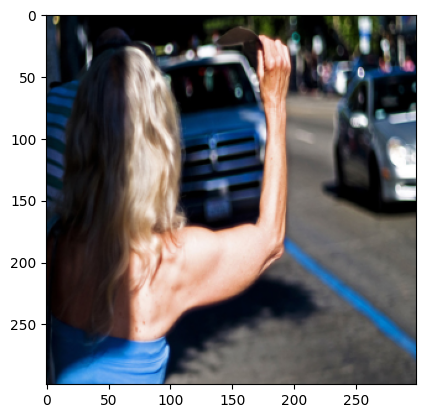

Example CORRECT: a blond woman in a blue shirt appears to wait for a ride .
Example OUTPUT: whistle comes hurdles dogs backstroke pajamas stretching porch boston boots downtown laugh clean covers thrown backstroke pajamas stretching porch boston boots downtown laugh clean covers thrown backstroke pajamas stretching porch boston boots downtown laugh clean covers thrown backstroke pajamas stretching


In [ ]:
print("\n--- Evaluation on Test Set (Attention Decoder - Recurrent State) ---")
def print_example(model, device, loader, dataset):
    model.eval()
    img, caption = next(iter(loader))
    caption = caption.transpose(0, 1)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    display_img = inv_normalize(img[0])
    plt.imshow(display_img.permute(1, 2, 0))
    plt.show()

    print("Example CORRECT: " + " ".join([dataset.vocab.itos[idx] for idx in caption[0].tolist()
      if dataset.vocab.itos[idx] not in {"<PAD>", "<BOS>", "<EOS>"}]))
    print(
        "Example OUTPUT: "
        + " ".join(model.caption_image(img[0].unsqueeze(0).to(device), dataset.vocab))
    )

print_example(model, device, test_loader, test_dataset)


## V2


--- Training Model with Two Attention Layers from Lab 6 ---
[Train 1] Iteration 100 | Running Loss: 7.9933
[Train 1] Iteration 200 | Running Loss: 7.9584
[Train 1] Iteration 300 | Running Loss: 7.9238
[Train 1] Iteration 400 | Running Loss: 7.8884
[Train 1] Iteration 500 | Running Loss: 7.8530
[Train 1] Iteration 600 | Running Loss: 7.8178
[Train 1] Iteration 700 | Running Loss: 7.7824
[Train 1] Iteration 800 | Running Loss: 7.7468
[Train 1] Iteration 900 | Running Loss: 7.7106
[Train] Epoch 1 | Average Loss: 7.6968
[Valid] Epoch 1 | Average Loss: 7.2458

--- Evaluation on Test Set (Two Attention Layers from Lab 6) ---


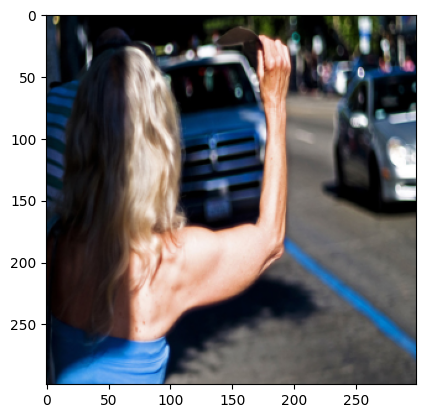

Example CORRECT: a blond woman in a blue shirt appears to wait for a ride .
Example OUTPUT: pitbull folded shawl greyhound passengers shoots soaked jacked circuit navy garage midair backpacks showing surfboarder bathrobe unseen grinds expression showing surfboarder bathrobe unseen grinds expression showing surfboarder bathrobe unseen grinds expression showing surfboarder bathrobe unseen grinds expression showing surfboarder bathrobe


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import spacy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile
import math

def download(url, cache_dir=os.path.join('.', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    fp = None
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

# Attention mechanisms from Lab 6
def sequence_mask(X, valid_len, value=0):
    """Mask irrelevant entries in sequences."""
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    """Perform softmax operation by masking elements on the last axis."""
    # `X`: 3D tensor, `valid_lens`: 1D or 2D tensor
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                          value=-1e6)
        return F.softmax(X.reshape(shape), dim=-1)

class AdditiveAttention(nn.Module):
    """Additive attention."""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # After dimension expansion, shape of `queries` is: (`batch_size`, no.
        # of queries, 1, `num_hiddens`) and shape of `keys` is: (`batch_size`,
        # 1, no. of key-value pairs, `num_hiddens`). Sum them up with
        # broadcasting
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # There is only one output of `self.w_v`, so we remove the last
        # one-dimensional entry from the shape. Shape of `scores` is:
        # (`batch_size`, no. of queries, no. of key-value pairs)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # Shape of `values` is: (`batch_size`, no. of key-value pairs, value
        # dimension)
        return torch.bmm(self.dropout(self.attention_weights), values)

class DotProductAttention(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # Shape of `queries` is: (`batch_size`, no. of queries, `d`)
    # Shape of `keys` is: (`batch_size`, no. of key-value pairs, `d`)
    # Shape of `values` is: (`batch_size`, no. of key-value pairs, value
    # dimension)
    # Shape of `valid_lens`: (`batch_size`,) or (`batch_size`, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Use `keys.transpose(1,2)` to swap the last two dimensions of `keys`
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flicker8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')

spacy_en = spacy.load('en_core_web_sm')

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<BOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1

                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

def load_captions(path):
    captions_list = []
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            caption = ' '.join(words[1:])
            captions_list.append(caption)
    return captions_list

vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))

def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_name = line.strip("\n").split(".")[0]
            img_names.append(img_name)

    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]

            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)

    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x:x + '\n', lines)
        file.writelines(lines)

split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")

class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])
        return img, torch.tensor(numericalized_caption)

class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)
        return imgs, targets

def get_loader(
    root_folder,
    annotation_file,
    vocab,
    transform,
    batch_size=32,
    num_workers=2,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)
    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]),
    )
    return loader, dataset

transform = transforms.Compose(
        [transforms.Resize((299, 299)),
         transforms.ToTensor(),
         transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
         ]
    )

train_loader, train_dataset = get_loader(
    "Flicker8k_Dataset", "train.txt", vocab, transform=transform
)
val_loader, val_dataset = get_loader(
    "Flicker8k_Dataset", "validation.txt", vocab, transform=transform
)
test_loader, test_dataset = get_loader(
    "Flicker8k_Dataset", "test.txt", vocab, transform=transform, shuffle=False
)

class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.inception(images)
        if isinstance(features, tuple):
            features = features[0]
        return self.dropout(self.relu(features))

class DecoderRNN(nn.Module):
    """Decoder with two attention layers from Lab 6:
    1. First attention: Attention on image features using embeddings as query (DotProductAttention)
       - This processes image features based on current embedding
    2. Second attention: Attention mixing embeddings with hidden state (AdditiveAttention)
       - This mixes the embedding with the hidden state
    """
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.embed_size = embed_size

        # Initialize hidden state from image features
        self.init_hidden = nn.Linear(embed_size, hidden_size)

        # First attention: Self-attention on image features (DotProductAttention)
        # This attention processes the image features themselves
        self.attention1 = DotProductAttention(dropout=0.1)

        # Project image features to match attention dimensions
        self.image_proj = nn.Linear(embed_size, embed_size)

        # Second attention: Attention that mixes embeddings with hidden state (AdditiveAttention)
        # This attention uses hidden state as query and embeddings as keys/values
        self.attention2 = AdditiveAttention(
            key_size=embed_size,
            query_size=hidden_size,
            num_hiddens=hidden_size,
            dropout=0.1
        )

        # Linear layer to combine attended features
        self.combine = nn.Linear(embed_size + hidden_size, hidden_size)

        # Output layer
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, image_features, captions):
        batch_size = image_features.shape[0]
        seq_len = captions.shape[0]

        outputs = torch.zeros(seq_len, batch_size, self.vocab_size, device=image_features.device)

        # Initialize hidden state from image features
        hidden_state = torch.tanh(self.init_hidden(image_features))

        # Project image features for first attention
        # Expand to (batch_size, 1, embed_size) for attention
        image_features_proj = self.image_proj(image_features).unsqueeze(1)  # (batch_size, 1, embed_size)

        # Get embeddings
        embeddings = self.dropout(self.embed(captions))  # Shape: (seq_len, batch_size, embed_size)

        # Process sequence step by step
        for t in range(seq_len):
            current_embedding = embeddings[t, :, :]  # Shape: (batch_size, embed_size)
            current_embedding_expanded = current_embedding.unsqueeze(1)  # Shape: (batch_size, 1, embed_size)

            # First attention: Attend to image features using current embedding as query
            attended_image = self.attention1(
                current_embedding_expanded,  # queries: embeddings
                image_features_proj,        # keys: image features
                image_features_proj,        # values: image features
                None
            )  # Shape: (batch_size, 1, embed_size)
            attended_image = attended_image.squeeze(1)  # Shape: (batch_size, embed_size)

            # Second attention: Mix embeddings with hidden state
            # Query: hidden_state, Keys/Values: current_embedding
            hidden_query = hidden_state.unsqueeze(1)  # Shape: (batch_size, 1, hidden_size)
            embedding_keys = current_embedding_expanded  # Shape: (batch_size, 1, embed_size)
            embedding_values = current_embedding_expanded  # Shape: (batch_size, 1, embed_size)

            attended_embedding = self.attention2(
                hidden_query,
                embedding_keys,
                embedding_values,
                None
            )  # Shape: (batch_size, 1, embed_size)
            attended_embedding = attended_embedding.squeeze(1)  # Shape: (batch_size, embed_size)

            # Combine attended image features and attended embedding
            combined = torch.cat([attended_image, attended_embedding], dim=1)  # Shape: (batch_size, embed_size + embed_size)
            hidden_state = torch.tanh(self.combine(combined))  # Shape: (batch_size, hidden_size)

            # Generate output
            outputs[t] = self.linear(hidden_state)

        return outputs

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=40):
        result_caption = []

        with torch.no_grad():
            encoder_features = self.encoderCNN(image)
            batch_size = encoder_features.shape[0]

            # Initialize hidden state
            hidden_state = torch.tanh(self.decoderRNN.init_hidden(encoder_features))

            # Project image features for first attention
            image_features_proj = self.decoderRNN.image_proj(encoder_features).unsqueeze(1)

            current_predicted_token_idx = vocabulary.stoi["<BOS>"]

            for _ in range(max_length):
                current_predicted_token_tensor = torch.tensor(
                    [current_predicted_token_idx],
                    device=encoder_features.device
                )
                current_embedding = self.decoderRNN.dropout(
                    self.decoderRNN.embed(current_predicted_token_tensor)
                )  # Shape: (1, embed_size)
                current_embedding_expanded = current_embedding.unsqueeze(1)  # Shape: (1, 1, embed_size)

                # First attention: Attend to image features using current embedding as query
                attended_image = self.decoderRNN.attention1(
                    current_embedding_expanded,  # queries: embeddings
                    image_features_proj,        # keys: image features
                    image_features_proj,        # values: image features
                    None
                ).squeeze(1)  # Shape: (1, embed_size)

                # Second attention: Mix embeddings with hidden state
                hidden_query = hidden_state.unsqueeze(1)  # Shape: (1, 1, hidden_size)
                embedding_keys = current_embedding_expanded  # Shape: (1, 1, embed_size)
                embedding_values = current_embedding_expanded  # Shape: (1, 1, embed_size)

                attended_embedding = self.decoderRNN.attention2(
                    hidden_query,
                    embedding_keys,
                    embedding_values,
                    None
                ).squeeze(1)  # Shape: (1, embed_size)

                # Combine attended image features and attended embedding
                combined = torch.cat([attended_image, attended_embedding], dim=1)
                hidden_state = torch.tanh(self.decoderRNN.combine(combined))

                # Generate output
                output_logits = self.decoderRNN.linear(hidden_state)
                predicted_word_idx = output_logits.argmax(1).item()
                result_caption.append(predicted_word_idx)

                if vocabulary.itos[predicted_word_idx] == "<EOS>":
                    break

                current_predicted_token_idx = predicted_word_idx

        return [vocabulary.itos[idx] for idx in result_caption]

embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 1
device = try_gpu()

model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)

for name, param in model.encoderCNN.inception.named_parameters():
    if "fc.weight" in name or "fc.bias" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
loss_criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])

train_loss = []
dev_loss = []

print("\n--- Training Model with Two Attention Layers from Lab 6 ---")
for epoch in range(num_epochs):
    model.train()

    train_run_loss = []
    index = 0

    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, captions)

        loss = loss_criterion(outputs[1:].reshape(-1, outputs.shape[2]), captions[1:].reshape(-1))
        loss.backward()
        optimizer.step()
        train_run_loss.append(loss.item())
        if (index+1) % 100 == 0:
            print(f"[Train {epoch+1}] Iteration {index+1} | Running Loss: {np.mean(train_run_loss):.4f}")
        index += 1

    avg_loss = np.mean(train_run_loss)
    train_loss.append(avg_loss)
    print(f"[Train] Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")

    index = 0
    dev_run_loss = []
    model.eval()
    for idx, (imgs, captions) in enumerate(val_loader):
        with torch.no_grad():
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions)
            loss = loss_criterion(outputs[1:].reshape(-1, outputs.shape[2]), captions[1:].reshape(-1))
            dev_run_loss.append(loss.item())
            index += 1

    avg_loss = np.mean(dev_run_loss)
    dev_loss.append(avg_loss)
    print(f"[Valid] Epoch {epoch+1} | Average Loss: {avg_loss:.4f}")

print("\n--- Evaluation on Test Set (Two Attention Layers from Lab 6) ---")
def print_example(model, device, loader, dataset):
    model.eval()
    img, caption = next(iter(loader))
    caption = caption.transpose(0, 1)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    display_img = inv_normalize(img[0])
    plt.imshow(display_img.permute(1, 2, 0))
    plt.show()

    print("Example CORRECT: " + " ".join([dataset.vocab.itos[idx] for idx in caption[0].tolist()
      if dataset.vocab.itos[idx] not in {"<PAD>", "<BOS>", "<EOS>"}]))
    print(
        "Example OUTPUT: "
        + " ".join(model.caption_image(img[0].unsqueeze(0).to(device), dataset.vocab))
    )

print_example(model, device, test_loader, test_dataset)


## V3 - acasa

In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import spacy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

In [2]:
def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    fp = zipfile.ZipFile(fname, 'r')
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [17]:
# Attention mechanisms from Lab 6
def sequence_mask(X, valid_len, value=0):
    """Mask irrelevant entries in sequences."""
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    """Perform softmax operation by masking elements on the last axis."""
    # `X`: 3D tensor, `valid_lens`: 1D or 2D tensor
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                          value=-1e6)
        return F.softmax(X.reshape(shape), dim=-1)

class AdditiveAttention(nn.Module):
    """Additive attention."""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # After dimension expansion, shape of `queries` is: (`batch_size`, no.
        # of queries, 1, `num_hiddens`) and shape of `keys` is: (`batch_size`,
        # 1, no. of key-value pairs, `num_hiddens`). Sum them up with
        # broadcasting
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # There is only one output of `self.w_v`, so we remove the last
        # one-dimensional entry from the shape. Shape of `scores` is:
        # (`batch_size`, no. of queries, no. of key-value pairs)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # Shape of `values` is: (`batch_size`, no. of key-value pairs, value
        # dimension)
        return torch.bmm(self.dropout(self.attention_weights), values)

class DotProductAttention(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # Shape of `queries` is: (`batch_size`, no. of queries, `d`)
    # Shape of `keys` is: (`batch_size`, no. of key-value pairs, `d`)
    # Shape of `values` is: (`batch_size`, no. of key-value pairs, value
    # dimension)
    # Shape of `valid_lens`: (`batch_size`,) or (`batch_size`, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Use `keys.transpose(1,2)` to swap the last two dimensions of `keys`
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

class PositionalEncoding(nn.Module):
    """Positional encoding."""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # Create a long enough `P`
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

def transpose_qkv(X, num_heads):
    """Transposition for parallel computation of multiple attention heads."""
    # Shape of input `X` is:
    # (`batch_size`, no. of queries or key-value pairs, `num_hiddens`).
    # Shape of output `X` is:
    # (`batch_size`, no. of queries or key-value pairs, `num_heads`,
    # `num_hiddens` / `num_heads`)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # Shape of output `X` is:
    # (`batch_size`, `num_heads`, no. of queries or key-value pairs,
    # `num_hiddens` / `num_heads`)
    X = X.permute(0, 2, 1, 3)

    # Shape of `output` is:
    # (`batch_size` * `num_heads`, no. of queries or key-value pairs,
    # `num_hiddens` / `num_heads`)
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    """Reverse the operation of `transpose_qkv`."""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

class MultiHeadAttention(nn.Module):
    """Multi-head attention."""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # Shape of `queries`, `keys`, or `values` is:
        # (`batch_size`, no. of queries or key-value pairs, `num_hiddens`)
        # Shape of `valid_lens` is:
        # (`batch_size`,) or (`batch_size`, no. of queries)
        # After transposing, shape of output `queries`, `keys`, or `values` is:
        # (`batch_size` * `num_heads`, no. of queries or key-value pairs,
        # `num_hiddens` / `num_heads`)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            # On axis 0, copy the first item (scalar or vector) for
            # `num_heads` times, then copy the next item, and so on
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # Shape of `output` is: (`batch_size` * `num_heads`, no. of queries,
        # `num_hiddens` / `num_heads`)
        output = self.attention(queries, keys, values, valid_lens)

        # Shape of `output_concat` is:
        # (`batch_size`, no. of queries, `num_hiddens`)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

In [4]:
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')

'./Flickr8k_text'

In [5]:
spacy_en = spacy.load('en_core_web_sm')

In [6]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<BOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1

                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

In [7]:
def load_captions(path):
    captions_list = []
    image_captions = {}
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            caption = ' '.join(words[1:])
            captions_list.append(caption)

    return captions_list

In [8]:
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))

In [9]:
def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_name = line.strip("\n").split(".")[0]
            img_names.append(img_name)

    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]

            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)

    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x:x + '\n', lines)
        file.writelines(lines)

In [10]:
split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")

In [11]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform

        # Get img, caption columns
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

In [12]:
class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)

        return imgs, targets

In [13]:
def get_loader(
    root_folder,
    annotation_file,
    vocab,
    transform,
    batch_size=32,
    num_workers=2,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]),
    )

    return loader, dataset

In [14]:
transform = transforms.Compose(
        [transforms.Resize((299, 299)),
         transforms.ToTensor(),
         transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
         ]
    )

train_loader, train_dataset = get_loader(
    "Flicker8k_Dataset", "train.txt", vocab, transform=transform
)

val_loader, val_dataset = get_loader(
    "Flicker8k_Dataset", "validation.txt", vocab, transform=transform
)

test_loader, test_dataset = get_loader(
    "Flicker8k_Dataset", "test.txt", vocab, transform=transform, shuffle=False
)

In [18]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.inception(images)[0]
        return self.dropout(self.relu(features))

In [19]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.pos_encoder = PositionalEncoding(embed_size, 0.1)

        # 1. Masked Self-Attention (Deals with one type of input: Captions)
        self.self_attention = MultiHeadAttention(
            key_size=embed_size,
            query_size=embed_size,
            value_size=embed_size,
            num_hiddens=embed_size,
            num_heads=8,
            dropout=0.1
        )
        self.norm1 = nn.LayerNorm(embed_size)

        # 2. Cross-Attention (Mixes embeddings with state/image features)
        self.cross_attention = MultiHeadAttention(
            key_size=embed_size,
            query_size=embed_size,
            value_size=embed_size,
            num_hiddens=embed_size,
            num_heads=8,
            dropout=0.1
        )
        self.norm2 = nn.LayerNorm(embed_size)

        # Feed Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(embed_size, embed_size * 2),
            nn.ReLU(),
            nn.Linear(embed_size * 2, embed_size)
        )
        self.norm3 = nn.LayerNorm(embed_size)

        self.out = nn.Linear(embed_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        # Captions shape: (seq_len, batch) -> Transpose to (batch, seq_len) for Attention
        # Features shape: (batch, embed_size)

        # 1. Prepare Inputs
        src = self.embed(captions).permute(1, 0, 2) # (batch, seq_len, embed_size)
        src = self.pos_encoder(src)

        batch_size = src.size(0)
        seq_len = src.size(1)

        # 2. Self Attention with Causal Masking
        # Create valid_lens to ensure position i only attends to positions 0...i
        # Shape: (batch, seq_len). Row content: [1, 2, 3, ..., seq_len]
        valid_lens = torch.arange(1, seq_len + 1, device=src.device).repeat(batch_size, 1)

        # Self Attention
        attn_output = self.self_attention(src, src, src, valid_lens)
        src = self.norm1(src + attn_output) # Add & Norm

        # 3. Cross Attention (Query=Captions, Key/Value=Image Features)
        # Reshape features to (batch, 1, embed_size) to act as a sequence of length 1
        image_kv = features.unsqueeze(1)

        # No masking needed for image attention (valid_lens=None implies attend to everything)
        attn_output = self.cross_attention(src, image_kv, image_kv, valid_lens=None)
        src = self.norm2(src + attn_output) # Add & Norm

        # 4. Feed Forward
        ffn_output = self.ffn(src)
        src = self.norm3(src + ffn_output)

        # 5. Output Head
        output = self.out(src) # (batch, seq_len, vocab_size)

        # Transpose back to (seq_len, batch, vocab_size) to match Loss calculation expectations
        return output.permute(1, 0, 2)

In [20]:
class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=40):
        result_caption = []

        with torch.no_grad():
            # Get image features: (1, embed_size)
            features = self.encoderCNN(image).unsqueeze(0)

            # Start with <BOS> token
            current_tokens = [vocabulary.stoi["<BOS>"]]

            for _ in range(max_length):
                # Prepare input tensor: (seq_len, 1) -> fits DataLoader logic,
                # but DecoderRNN handles the transpose internally.
                captions_input = torch.LongTensor(current_tokens).unsqueeze(1).to(image.device)

                # Run the model
                # Note: Transformers are stateless, so we feed the full growing sequence every time.
                outputs = self.decoderRNN(features, captions_input)

                # Get the prediction for the last token only
                # outputs shape: (seq_len, batch=1, vocab_size)
                last_token_logits = outputs[-1, 0, :]
                predicted = last_token_logits.argmax(0).item()

                if vocabulary.itos[predicted] == "<EOS>":
                    break

                result_caption.append(predicted)
                current_tokens.append(predicted)

        return [vocabulary.itos[idx] for idx in result_caption]

In [21]:
embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 1
device = try_gpu()
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 199MB/s] 


In [22]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
loss_criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])

In [23]:
for name, param in model.encoderCNN.inception.named_parameters():
        if "fc.weight" in name or "fc.bias" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

In [27]:
import torch
import torch.nn as nn
import numpy as np
import math

In [28]:
train_loss = [] #5 min
dev_loss = []

for epoch in range(num_epochs):
    model.train()

    train_run_loss = []
    dev_run_loss = []
    index = 0

    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        outputs = model(imgs, captions)
        loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
        loss.backward()
        optimizer.step()
        train_run_loss.append(loss.item())
        if (index+1) % 100 == 0:
            print("[Train {}] Iteration {} | Running Loss: {}".format(epoch+1, index+1, round(np.mean(train_run_loss), 4)))
        index += 1

    avg_loss = np.mean(train_run_loss)
    train_loss.append(avg_loss)
    print("[Train] Epoch {} | Average Loss: {}".format(epoch+1, round(avg_loss, 4)))

    index = 0
    for idx, (imgs, captions) in enumerate(val_loader):
        with torch.no_grad():
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions)
            loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
            dev_run_loss.append(loss.item())
            index += 1

    avg_loss = np.mean(dev_run_loss)
    dev_loss.append(avg_loss)
    print("[Valid] Epoch {} | Average Loss: {}".format(epoch+1, round(avg_loss, 4)))

[Train 1] Iteration 100 | Running Loss: 8.0785
[Train 1] Iteration 200 | Running Loss: 7.9506
[Train 1] Iteration 300 | Running Loss: 7.8179
[Train 1] Iteration 400 | Running Loss: 7.6864
[Train 1] Iteration 500 | Running Loss: 7.5563
[Train 1] Iteration 600 | Running Loss: 7.4265
[Train 1] Iteration 700 | Running Loss: 7.2988
[Train 1] Iteration 800 | Running Loss: 7.1724
[Train 1] Iteration 900 | Running Loss: 7.0487
[Train] Epoch 1 | Average Loss: 7.0037
[Valid] Epoch 1 | Average Loss: 5.9067


In [29]:
def print_example(model, device, loader, dataset):
    model.eval()
    img, caption = next(iter(loader))
    caption = caption.transpose(0, 1)
    plt.imshow(img[0].permute(1, 2, 0))
    print("Example CORRECT: " + " ".join([dataset.vocab.itos[idx] for idx in caption[0].tolist()
      if dataset.vocab.itos[idx] not in {"<PAD>", "<BOS>", "<EOS>"}]))
    print(
        "Example OUTPUT: "
        + " ".join(model.caption_image(img[0].unsqueeze(0).to(device), dataset.vocab))
    )

Example CORRECT: a blond woman in a blue shirt appears to wait for a ride .
Example OUTPUT: <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS> <BOS>


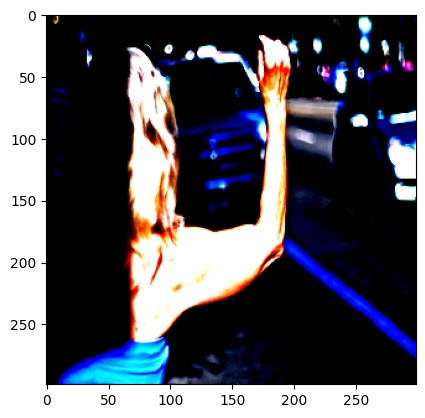

In [30]:
print_example(model, device, test_loader, test_dataset)